In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install matplotlib
!pip install pylatexenc

In [6]:
from qiskit import QuantumCircuit
import numpy as np

In [7]:
qc = QuantumCircuit.from_qasm_file("P9_grand_summit.qasm")

print("Qubits:", qc.num_qubits)
print("Depth:", qc.depth())

Qubits: 56
Depth: 93


In [8]:
qc = qc.decompose().decompose()

In [9]:
angles = [0.0] * qc.num_qubits

for instr in qc.data:

    op = instr.operation
    qubits = [q._index for q in instr.qubits]

    if op.name == "ry":
        angles[qubits[0]] += float(op.params[0])

    elif op.name == "rx":
        angles[qubits[0]] += float(op.params[0])

    elif op.name == "rz":
        angles[qubits[0]] += float(op.params[0])

    elif op.name in ["u", "u3"]:
        angles[qubits[0]] += float(op.params[0])

In [10]:
bits = []

for theta in angles:

    p0 = np.cos(theta/2)**2
    p1 = np.sin(theta/2)**2

    bits.append("1" if p1 > p0 else "0")

peak = "".join(bits[::-1])

print("Predicted peak bitstring:")
print(peak)

Predicted peak bitstring:
01001111100010000110100101000110101010111010010010111111


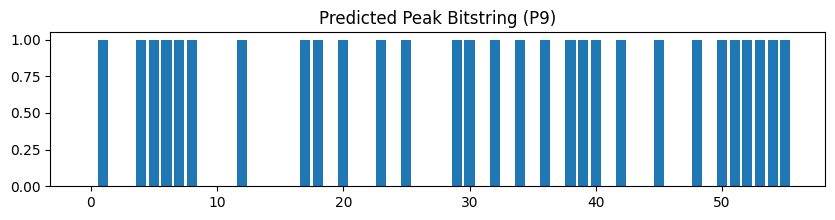

In [11]:
import matplotlib.pyplot as plt

values = [int(b) for b in peak]

plt.figure(figsize=(10,2))
plt.bar(range(len(values)), values)
plt.title("Predicted Peak Bitstring (P9)")
plt.show()